# VET Data

**Importing Package**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Loading Sheets**

In [2]:
# Load Excel file
file_path = 'VET_Data_task1.xlsx'
xls = pd.ExcelFile(file_path)
print("Available Sheets:", xls.sheet_names)

Available Sheets: ['Tasks', 'Data Dictionary', 'Organisation', 'Contract', 'Student', 'Enrolment']


In [3]:
# Load individual sheets based on the Data Dictionary
organisation_df = pd.read_excel(xls, sheet_name='Organisation')
contract_df = pd.read_excel(xls, sheet_name='Contract')
student_df = pd.read_excel(xls, sheet_name='Student')
enrolment_df = pd.read_excel(xls, sheet_name='Enrolment')

In [4]:
# Display basic info and first few rows
display(contract_df.head(10))

,Provider_ID,Funding_Source,Contract_Number,Target_AHC_Total,Target_AHC_Urban,Target_AHC_Regional,Target_AHC_Remote,Contract_Start_Date,Contract_End_Date
0,P001,11J,DCVT-2001,41000,19438,9730,11832,2023-01-01,2025-12-31
1,P001,FFT,DCVT-2002,28280,11938,7804,8538,2023-01-01,2025-12-31
2,P002,11K,DCVT-2003,26130,11434,5515,9181,2023-01-01,2025-12-31
3,P002,FFT,DCVT-2004,30510,9953,6110,14447,2023-01-01,2025-12-31
4,P002,11V,DCVT-2005,25890,9139,10301,6449,2023-01-01,2025-12-31
5,P002,11J,DCVT-2006,10400,4100,2175,4124,2023-01-01,2025-12-31
6,P003,11N,DCVT-2007,26870,15069,7803,3998,2023-01-01,2025-12-31
7,P003,FFT,DCVT-2008,0,8969,6423,9478,2023-01-01,2025-12-31
8,P004,11N,DCVT-2009,40280,22522,14062,3696,2023-01-01,2025-12-31
9,P004,FFT,DCVT-2010,19180,10952,4590,3638,2023-01-01,2025-12-31


**Data Cleaning**

In [5]:
# Convert all columns to lowercase
contract_df.columns = contract_df.columns.str.lower()

In [6]:
# Check data types and non-null counts
contract_df.info()

# Check for missing values per column
print("\nMissing Values:")
print(contract_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   provider_id          23 non-null     object        
 1   funding_source       23 non-null     object        
 2   contract_number      23 non-null     object        
 3   target_ahc_total     23 non-null     int64         
 4   target_ahc_urban     23 non-null     int64         
 5   target_ahc_regional  23 non-null     int64         
 6   target_ahc_remote    23 non-null     int64         
 7   contract_start_date  23 non-null     datetime64[ns]
 8   contract_end_date    23 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(4), object(3)
memory usage: 1.7+ KB

Missing Values:
provider_id            0
funding_source         0
contract_number        0
target_ahc_total       0
target_ahc_urban       0
target_ahc_regional    0
target_ahc_remote      0
contract_s

In [7]:
# Checking duplicates
exact_dupes_count = contract_df.duplicated().sum()
print("Exact duplicate rows:", exact_dupes_count)

# Remove duplicates if any exist
if exact_dupes_count > 0:
    contract_df = contract_df.drop_duplicates().reset_index(drop=True)
    print("Total rows after removing duplicates:", len(contract_df))

Exact duplicate rows: 0


In [8]:
display(contract_df)

,provider_id,funding_source,contract_number,target_ahc_total,target_ahc_urban,target_ahc_regional,target_ahc_remote,contract_start_date,contract_end_date
0,P001,11J,DCVT-2001,41000,19438,9730,11832,2023-01-01,2025-12-31
1,P001,FFT,DCVT-2002,28280,11938,7804,8538,2023-01-01,2025-12-31
2,P002,11K,DCVT-2003,26130,11434,5515,9181,2023-01-01,2025-12-31
3,P002,FFT,DCVT-2004,30510,9953,6110,14447,2023-01-01,2025-12-31
4,P002,11V,DCVT-2005,25890,9139,10301,6449,2023-01-01,2025-12-31
5,P002,11J,DCVT-2006,10400,4100,2175,4124,2023-01-01,2025-12-31
6,P003,11N,DCVT-2007,26870,15069,7803,3998,2023-01-01,2025-12-31
7,P003,FFT,DCVT-2008,0,8969,6423,9478,2023-01-01,2025-12-31
8,P004,11N,DCVT-2009,40280,22522,14062,3696,2023-01-01,2025-12-31
9,P004,FFT,DCVT-2010,19180,10952,4590,3638,2023-01-01,2025-12-31


**Exploratory Data Analysis (EDA)**

In [9]:
# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [10]:
print(contract_df.columns.tolist())

['provider_id', 'funding_source', 'contract_number', 'target_ahc_total', 'target_ahc_urban', 'target_ahc_regional', 'target_ahc_remote', 'contract_start_date', 'contract_end_date']


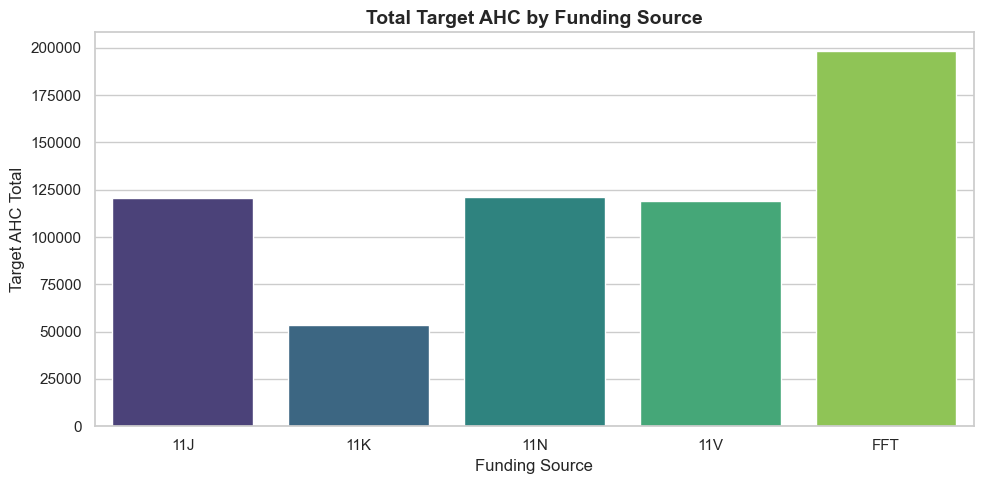

In [11]:
plt.figure(figsize=(10, 5))

# Group by lowercase column names
funding_summary = contract_df.groupby('funding_source')['target_ahc_total'].sum().reset_index()

sns.barplot(
    data=funding_summary,
    x='funding_source',
    y='target_ahc_total',
    hue='funding_source',
    legend=False,
    palette='viridis'
)

plt.title('Total Target AHC by Funding Source', fontsize=14, fontweight='bold')
plt.xlabel('Funding Source', fontsize=12)
plt.ylabel('Target AHC Total', fontsize=12)
plt.tight_layout()
plt.show()

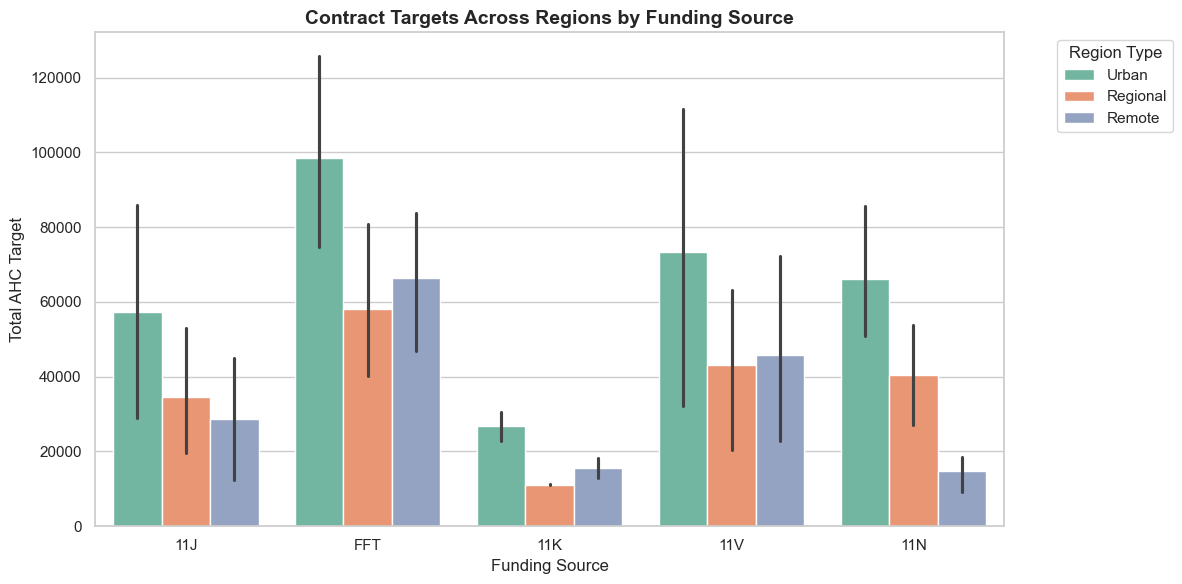

In [12]:
# Melt the dataframe to combine the regional target columns into a long format
melted_contract = contract_df.melt(
    id_vars=['funding_source', 'contract_number'],
    value_vars=['target_ahc_urban', 'target_ahc_regional', 'target_ahc_remote'],
    var_name='region_type',
    value_name='target_value'
)

# Clean up the region labels for a nicer chart display (e.g., 'Urban', 'Regional', 'Remote')
melted_contract['region_type'] = (
    melted_contract['region_type']
    .str.replace('target_ahc_', '')
    .str.capitalize()
)

# Plot grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=melted_contract,
    x='funding_source',
    y='target_value',
    hue='region_type',
    palette='Set2',
    estimator='sum'  # Sums the targets if multiple contracts share the same funding source
)

plt.title('Contract Targets Across Regions by Funding Source', fontsize=14, fontweight='bold')
plt.xlabel('Funding Source', fontsize=12)
plt.ylabel('Total AHC Target', fontsize=12)
plt.legend(title='Region Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()